## How does the Unconditional Guidance Scale shape the fidelity-diversity trade-off across cifar10 classes? Are there any class-specific sensitivities?



##### The analysis focuses on the generator and the objective is to assess the impact that the UGS has on synthetic images with respect to two aspects - fidelity and diversity - across cifar10 classes. The fidelity of a class generated with a specific UGS value will be assessed considering the accuracy of the resnet20 (trained on real cifar10) on the classification task. However, diversity will be measured by employing the LPIPS metric that measures perceptual similarity bewteen pairs of images.

In [1]:
%matplotlib inline

import os
import sys

# The project's code uses paths relative to the repository root. The check keeps
# the cell idempotent when re-run.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

In [2]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import tensorflow as tf

2026-09-11 13:31:37.510393: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-11 13:31:37.561827: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-11 13:31:37.563967: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-11 13:31:40.856621: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## IMAGE GENERATION

##### Let's start by loading the class-conditioned Stable Diffusion generator using the fine-tuned diffusion model and the trained Class Encoder checkpoints for CIFAR-10 to generate one image per class in order to check if everything works smoothly.

In [3]:
# Load the generator for cifar10

from Models.stable_diffusion import MyStableDiffusion
from Data.target_datasets import Cifar10

# CIFAR-10 information
dataset = Cifar10.CIFAR10()
class_names = dataset.get_labels()

NUM_CLASSES = len(class_names)

# Checkpoints
enc_weights_path = "Models/Checkpoints/DDPM/Exp_xAI/cifar10/MyEmbedding/epoch31.hdf5"
dif_weights_path = "Models/Checkpoints/DDPM/Exp_xAI/cifar10/DiffusionFt/epoch10.hdf5"

generator = MyStableDiffusion(
    res=32,
    num_classes=NUM_CLASSES,
    original_diffusion=True,
    original_text_encoder=False,
    enc_weight_path=enc_weights_path,
    diff_weight_path=dif_weights_path
)

print("Generator loaded.")
print(class_names)

Using TensorFlow backend


/home/matteo.doria/miniforge3/envs/sd_dataset/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-09-11 13:31:55.795280: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Weights loaded from  Models/Checkpoints/DDPM/Exp_xAI/cifar10/DiffusionFt/epoch10.hdf5
... Loading Embedding model weights from Models/Checkpoints/DDPM/Exp_xAI/cifar10/MyEmbedding/epoch31.hdf5 ...
DONE
Generator loaded.
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
# Generate one image per class

labels = tf.eye(NUM_CLASSES)

images = generator.gen(
    inputs=labels,
    num_images=NUM_CLASSES,
    num_inference_steps=20,
    ugs=1.0,
    seed=1234
)

print(images.shape)


... Generating 10 images ...
20/20 [==============================] - 281s 14s/step
(10, 128, 128, 3)


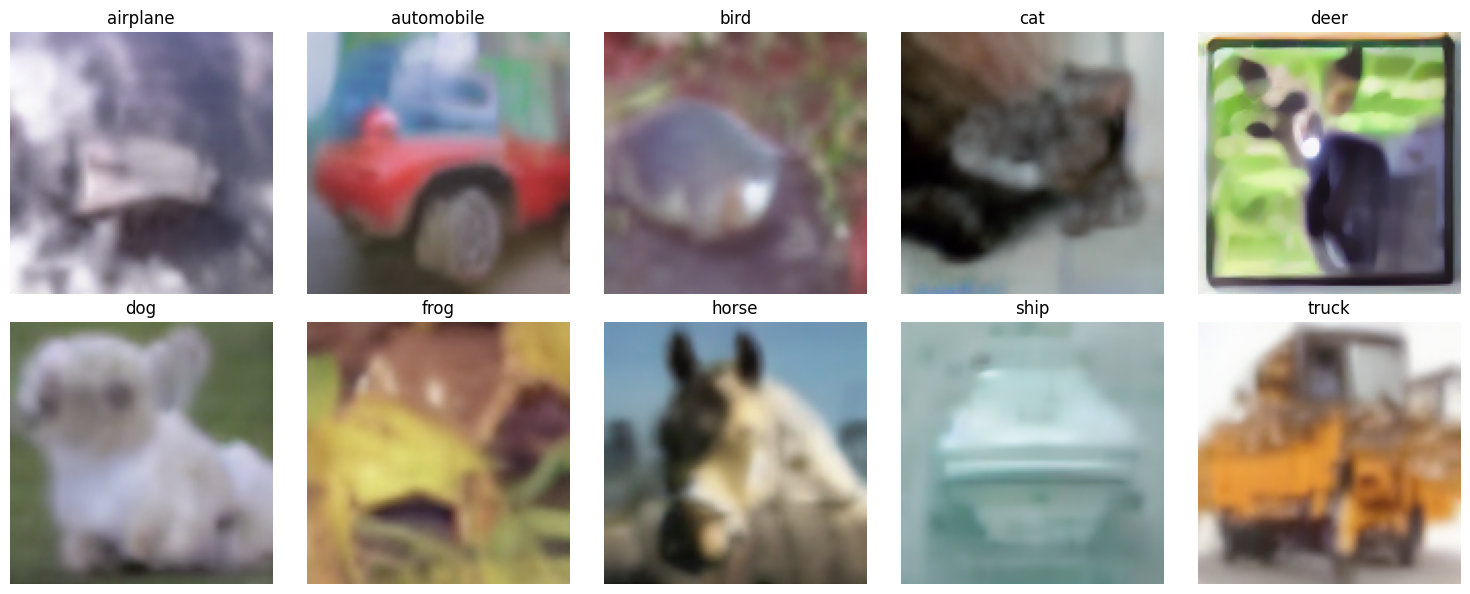

In [5]:
# show generated images

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.set_title(class_names[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

##### Since everything is working fine, we can now generate more images for the purpose of the analysis. Therefore, we create a separate generate_cifar10.py file to generate 100 images per class letting the UGS vary in [0.0, 0.5, 1.0, 2.0, 4.0, 7.5]. Therefore, 100 x 10 (classes) x 6 (UGS values) = 6000 images are generated and saved in the Data/Synthetic/Exp_xAI/cifar10 folder. The current notebook will load the images directly from there to carry out the analysis on both fidelity and diversity. The same random seed is used across experimental conditions to enable controlled comparisons of the effect of guidance strength.

## FIDELITY

#####  In the current section, we are interested in understanding to what extent the generator produces images that are semantically consistent with the conditioning class, and how this fidelity varies across target classes and UGS values. Therefore, the idea is to quantify fidelity through the performance of a classifier trained exclusively on real data, using its predictions on the generated images as a measure of class consistency.

In [6]:
# import the classifier model architecture: resnet20

from Models.ImageClassifiers import resnet

SEED = 1234
NUM_CLASSES = 10
INPUT_SHAPE = (32, 32, 3)

classifier = resnet.ResNet20(
    input_shape=INPUT_SHAPE,
    num_classes=NUM_CLASSES,
    initial_filters=64,
    seed=SEED
)

classifier.summary()

Model: "ResNet20"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer (InputLayer)    [(None, 32, 32, 3)]          0         []                            
                                                                                                  
 conv0 (Conv2D)              (None, 32, 32, 64)           1728      ['input_layer[0][0]']         
                                                                                                  
 bn0 (BatchNormalization)    (None, 32, 32, 64)           256       ['conv0[0][0]']               
                                                                                                  
 relu0 (ReLU)                (None, 32, 32, 64)           0         ['bn0[0][0]']                 
                                                                                           

##### We load the weights coming from training the classifier on the real cifar10 dataset

In [7]:
checkpoint_path = "Models/Checkpoints/Classifiers/resnet20/cifar10/real/best_model.h5"

classifier.load_weights(checkpoint_path)

print("Weights loaded successfully.")

Weights loaded successfully.


##### The generator produces 128 × 128 RGB images, whereas the classifier expects an input resolution of 32 × 32 pixels. Therefore, each generated image is first spatially resized to 32 × 32. In addition, the classifier was trained on images whose RGB channel values were normalized from the integer range [0, 255] to the floating-point range [0, 1]. To ensure consistency with the classifier’s training preprocessing, the same normalization is applied to the synthetic images by dividing each pixel-channel value by 255 before classification.

In [8]:
# create a loader for synthetic images + image preprocessing

BASE_PATH = "Data/Synthetic/Exp_xAI/cifar10/UGS_analysis_Enc31_Dif10_Is20"

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

CLASS_DIRS = [
    f"class_{i:02d}_{name}"
    for i, name in enumerate(CLASS_NAMES)
]


def load_synthetic_ugs(ugs, batch_size=64):
    path = os.path.join(BASE_PATH, f"ugs_{ugs}")

    ds = tf.keras.utils.image_dataset_from_directory(
        path,
        class_names=CLASS_DIRS,
        label_mode="categorical",
        image_size=(32, 32),
        interpolation="bilinear",
        batch_size=batch_size,
        shuffle=False
    )

    
    ds = ds.map(
        lambda images, labels: (
            tf.cast(images, tf.float32) / 255.0,
            labels
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    return ds.prefetch(tf.data.AUTOTUNE)

##### Now, we employ the classifier on the synthetic images to get prediction accuracies for the different classes and ugs values.

In [10]:
import numpy as np
import pandas as pd

# this code outputs a dictionary in the following format
# {ugs: [accuracy_class0, accuracy_class1, ..., accuracy_class9]}

UGS_VALUES = [0.0, 0.5, 1.0, 2.0, 4.0, 7.5]

accuracy_results = {}

for ugs in UGS_VALUES:
    
    print(f"\nEvaluating UGS = {ugs}")
    
    synthetic_ds = load_synthetic_ugs(ugs)

    # Correct predictions and total samples for each class
    correct_per_class = np.zeros(len(CLASS_NAMES), dtype=int)
    total_per_class = np.zeros(len(CLASS_NAMES), dtype=int)

    for images, labels in synthetic_ds:

        # True class = class used to condition the generator
        true_classes = tf.argmax(labels, axis=1).numpy()

        # ResNet20 predictions
        probs = classifier(images, training=False)
        predicted_classes = tf.argmax(probs, axis=1).numpy()

        for class_id in range(len(CLASS_NAMES)):
            mask = true_classes == class_id

            total_per_class[class_id] += np.sum(mask)

            correct_per_class[class_id] += np.sum(
                predicted_classes[mask] == class_id
            )

    class_accuracies = correct_per_class / total_per_class

    accuracy_results[ugs] = class_accuracies


Evaluating UGS = 0.0
Found 1000 files belonging to 10 classes.

Evaluating UGS = 0.5
Found 1000 files belonging to 10 classes.

Evaluating UGS = 1.0
Found 1000 files belonging to 10 classes.

Evaluating UGS = 2.0
Found 1000 files belonging to 10 classes.

Evaluating UGS = 4.0
Found 1000 files belonging to 10 classes.

Evaluating UGS = 7.5
Found 1000 files belonging to 10 classes.


##### We create a summary table of prediction accuracy results. Values in the tale range from 0 (all synthetic images from class X are classfied as belonging to other classes) to 1 (all synthetic images from class X are classified as belonging to class X). We also report the overall prediction accuracy for each ugs value and color in red/green the classes that have a prediction accuracy lower/higher than the overall prediction.

In [11]:
accuracy_df = pd.DataFrame(
    accuracy_results,
    index=CLASS_NAMES
)

accuracy_df.columns = [
    f"UGS {ugs}" for ugs in UGS_VALUES
]


from IPython.display import HTML, display

accuracy_df.loc["Overall"] = accuracy_df.loc[CLASS_NAMES].mean(axis=0)

html = "<table>"
html += "<tr><th></th>"

for col in accuracy_df.columns:
    html += f"<th>{col}</th>"

html += "</tr>"

for idx, row in accuracy_df.iterrows():
    html += f"<tr><th>{idx}</th>"

    for col, value in row.items():

        overall = accuracy_df.loc["Overall", col]

        if idx == "Overall":
            style = "font-weight:bold; color:black;"
        elif value > overall:
            style = "color:green;"
        elif value < overall:
            style = "color:red;"
        else:
            style = "color:black;"

        html += f'<td style="{style}">{value:.3f}</td>'

    html += "</tr>"

html += "</table>"

display(HTML(html))

,UGS 0.0,UGS 0.5,UGS 1.0,UGS 2.0,UGS 4.0,UGS 7.5
airplane,0.060,0.300,0.610,0.920,0.970,0.970
automobile,0.040,0.200,0.630,0.970,0.990,0.980
bird,0.040,0.200,0.490,0.840,0.990,0.960
cat,0.290,0.550,0.750,0.840,0.940,0.970
deer,0.100,0.360,0.650,0.930,0.990,0.980
dog,0.170,0.350,0.630,0.830,0.940,0.910
frog,0.030,0.200,0.540,0.920,0.980,1.000
horse,0.060,0.320,0.610,0.960,0.970,0.990
ship,0.090,0.360,0.730,0.980,0.990,0.990
truck,0.120,0.390,0.770,0.940,0.970,0.970


##### By looking at the overall accuracy prediction it is possible to notice how much the UGS value impacts the fidelity of the generated images. In particular, a big jump can be observed between a UGS value of 1 and 2, where the overall prediction accuracy goes from 0.641 to 0.913 (very high already!). Coloring the single values in red or green according to whether they are lower or higher than the overall per class, allows us to notice that classes that performs relatively better with lower ugs values may perform relatively worse with higher ugs value. And this is the case of the "truck", "dog" and "cat" classes. The coverse also holds for the ""frog" and the "automobile" for example. Only the "deer" class performs always performs reltively better than the average. No class performs always worse than the average, however the closest is the "bird". So, in general and according to this metric evaluation, we cannot state that the generator is better at producing certain classes than others. It depends on the chosen UGS value. 

In [12]:
class_accuracy_df = accuracy_df.drop(index="Overall")

dispersion_df = pd.DataFrame({
    "Mean accuracy": class_accuracy_df.mean(axis=0),
    "Min": class_accuracy_df.min(axis=0),
    "Max": class_accuracy_df.max(axis=0),
    "Range": class_accuracy_df.max(axis=0) - class_accuracy_df.min(axis=0),
    "Std. dev.": class_accuracy_df.std(axis=0, ddof=0)
})

dispersion_df

,Mean accuracy,Min,Max,Range,Std. dev.
UGS 0.0,0.100,0.03,0.29,0.26,0.075366
UGS 0.5,0.323,0.20,0.55,0.35,0.102669
UGS 1.0,0.641,0.49,0.77,0.28,0.084670
UGS 2.0,0.913,0.83,0.98,0.15,0.053488
UGS 4.0,0.973,0.94,0.99,0.05,0.018466
UGS 7.5,0.972,0.91,1.00,0.09,0.023580


##### From this table it is possible to observe how the range of accuracy prediction decrease when the increasing the UGS value. In particular there is a significant drop going from a UGS value of 1 to 2, meaning that starting from a UGS value of 2 synthetic images are generally more consistent to the real class, independently of the class. 

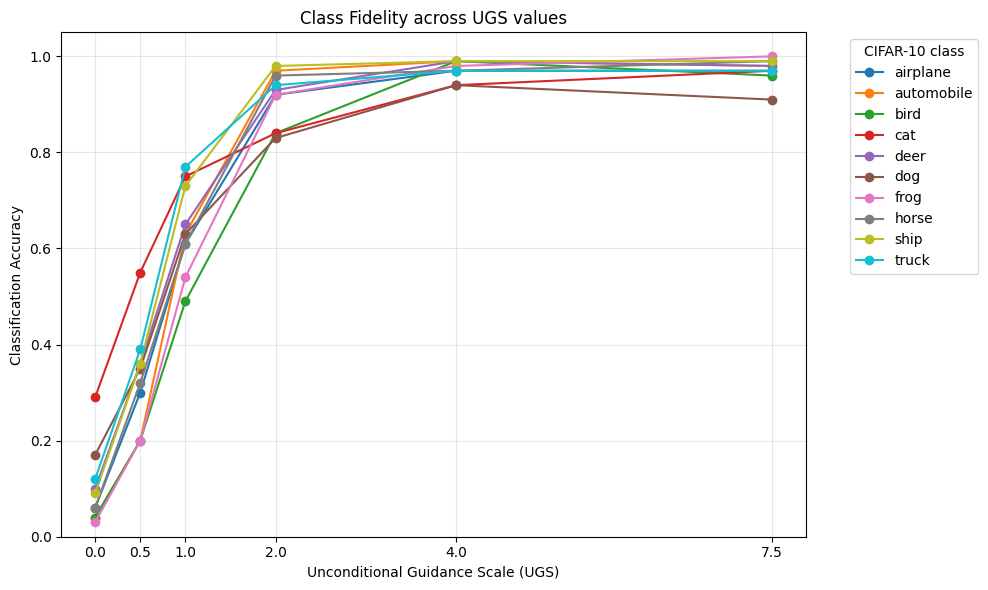

In [13]:
ugs_values = [0.0, 0.5, 1.0, 2.0, 4.0, 7.5]

plt.figure(figsize=(10, 6))

for class_name in CLASS_NAMES:
    plt.plot(
        ugs_values,
        accuracy_df.loc[class_name].values,
        marker="o",
        label=class_name
    )

plt.xlabel("Unconditional Guidance Scale (UGS)")
plt.ylabel("Classification Accuracy")
plt.title("Class Fidelity across UGS values")

plt.xticks(ugs_values)
plt.ylim(0, 1.05)

plt.legend(
    title="CIFAR-10 class",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##### This graph beautifully mirrors the two summary tables above. On one hand, we can appreciate some lines crossing each other reflecting the fact that the rank of class performances  varies across different UGS values. On the other hand, we can observe points getting closer on the y-axis in correspondance of a UGS value of 2 and be extremely closer at 4 and 7.5. This reflecting the fact that the overall prediction accuracy drammatically ioncreases with UGS values greater than 2.  

##### While prediction accuracy provides a direct measure of how often the generated images are classified as belonging to their intended target class, it only considers the class receiving the highest predicted score. Consequently, it does not capture the classifier’s degree of confidence or distinguish between borderline and unambiguous predictions. The mean target-class probability provides a more nuanced and continuous measure by quantifying how much probability the classifier assigns to the intended class across all generated images, including those that are ultimately misclassified. Considering both metrics therefore offers a more complete evaluation of class consistency: accuracy measures how frequently the generator produces recognizable examples of the requested class, while mean target-class probability indicates how strongly the characteristic features of that class are represented.

In [14]:
UGS_VALUES = [0.0, 0.5, 1.0, 2.0, 4.0, 7.5]

mean_target_prob_results = {}

for ugs in UGS_VALUES:

    print(f"\nEvaluating UGS = {ugs}")

    synthetic_ds = load_synthetic_ugs(ugs)

    # Sum of target-class probabilities for each class
    prob_sum_per_class = np.zeros(len(CLASS_NAMES), dtype=float)
    total_per_class = np.zeros(len(CLASS_NAMES), dtype=int)

    for images, labels in synthetic_ds:

        # Class used to condition the generator
        true_classes = tf.argmax(labels, axis=1).numpy()

        # ResNet20 class probabilities
        probs = classifier(images, training=False).numpy()

        for class_id in range(len(CLASS_NAMES)):

            mask = true_classes == class_id

            # Probability assigned to the requested class
            target_probs = probs[mask, class_id]

            prob_sum_per_class[class_id] += target_probs.sum()
            total_per_class[class_id] += len(target_probs)

    mean_target_prob_results[ugs] = (
        prob_sum_per_class / total_per_class
    )


Evaluating UGS = 0.0
Found 1000 files belonging to 10 classes.

Evaluating UGS = 0.5
Found 1000 files belonging to 10 classes.

Evaluating UGS = 1.0
Found 1000 files belonging to 10 classes.

Evaluating UGS = 2.0
Found 1000 files belonging to 10 classes.

Evaluating UGS = 4.0
Found 1000 files belonging to 10 classes.

Evaluating UGS = 7.5
Found 1000 files belonging to 10 classes.


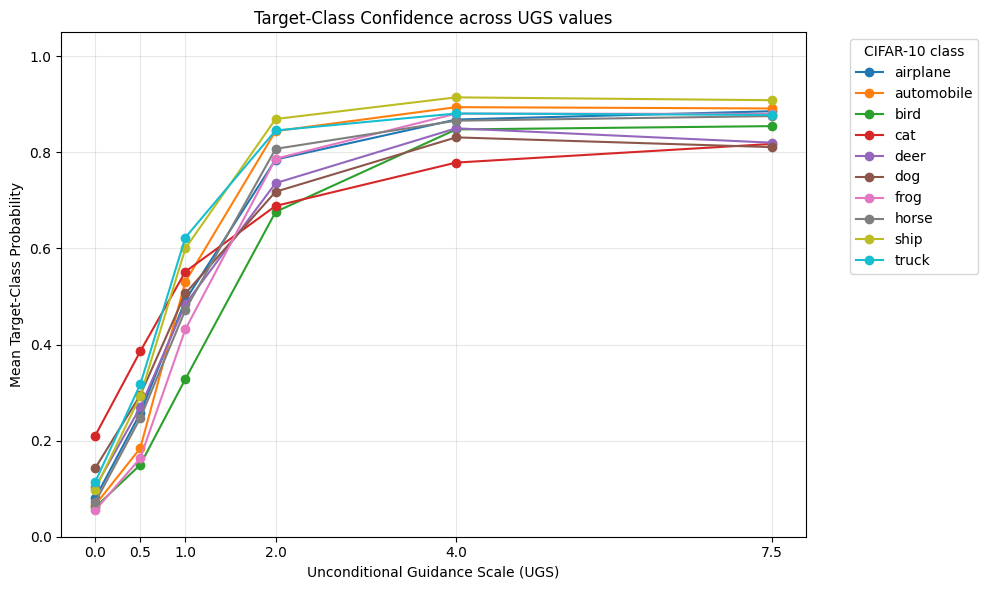

In [15]:
plt.figure(figsize=(10, 6))

mean_target_prob_df = pd.DataFrame(
    mean_target_prob_results,
    index=CLASS_NAMES
)

for class_name in CLASS_NAMES:
    plt.plot(
        UGS_VALUES,
        mean_target_prob_df.loc[class_name].values,
        marker="o",
        label=class_name
    )

plt.xlabel("Unconditional Guidance Scale (UGS)")
plt.ylabel("Mean Target-Class Probability")
plt.title("Target-Class Confidence across UGS values")

plt.xticks(UGS_VALUES)
plt.ylim(0, 1.05)

plt.legend(
    title="CIFAR-10 class",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##### Considering the mean target class probabilities instead of the prediction accuracies leaves the observations above unchanged. 

## DIVERSITY

##### After analyzing the fidelity of the synthetic images, we move on to study the impact that the UGS has on the diversity of such generated images. 

##### We employ the mean pairwise cosine distance measure on the features extracted by the ResNet20

In [16]:
feature_extractor = tf.keras.Model(
    inputs=classifier.input,
    outputs=classifier.get_layer("gap").output
)

print("Feature dimension:", feature_extractor.output_shape)

Feature dimension: (None, 256)


In [17]:
def mean_pairwise_cosine_distance(features):
    
    # Normalize each feature vector
    norms = np.linalg.norm(features, axis=1, keepdims=True)
    features_normalized = features / np.clip(norms, 1e-12, None)

    # Cosine similarity between all pairs
    similarity = features_normalized @ features_normalized.T

    # Convert similarity to distance
    distance = 1 - similarity

    # Keep only unique pairs, excluding the diagonal
    upper_triangle = distance[
        np.triu_indices(len(features), k=1)
    ]

    return upper_triangle.mean()

In [18]:
diversity_results = {}

for ugs in UGS_VALUES:

    print(f"\nEvaluating UGS = {ugs}")

    synthetic_ds = load_synthetic_ugs(ugs)

    features_per_class = {
        class_id: []
        for class_id in range(len(CLASS_NAMES))
    }

    for images, labels in synthetic_ds:

        # Extract ResNet20 features
        features = feature_extractor(
            images,
            training=False
        ).numpy()

        true_classes = tf.argmax(
            labels,
            axis=1
        ).numpy()

        # Store features by conditioning class
        for class_id in range(len(CLASS_NAMES)):
            mask = true_classes == class_id

            if np.any(mask):
                features_per_class[class_id].append(
                    features[mask]
                )

    class_diversities = []

    for class_id in range(len(CLASS_NAMES)):

        class_features = np.concatenate(
            features_per_class[class_id],
            axis=0
        )

        diversity = mean_pairwise_cosine_distance(
            class_features
        )

        class_diversities.append(diversity)

    diversity_results[ugs] = class_diversities


Evaluating UGS = 0.0
Found 1000 files belonging to 10 classes.

Evaluating UGS = 0.5
Found 1000 files belonging to 10 classes.

Evaluating UGS = 1.0
Found 1000 files belonging to 10 classes.

Evaluating UGS = 2.0
Found 1000 files belonging to 10 classes.

Evaluating UGS = 4.0
Found 1000 files belonging to 10 classes.

Evaluating UGS = 7.5
Found 1000 files belonging to 10 classes.


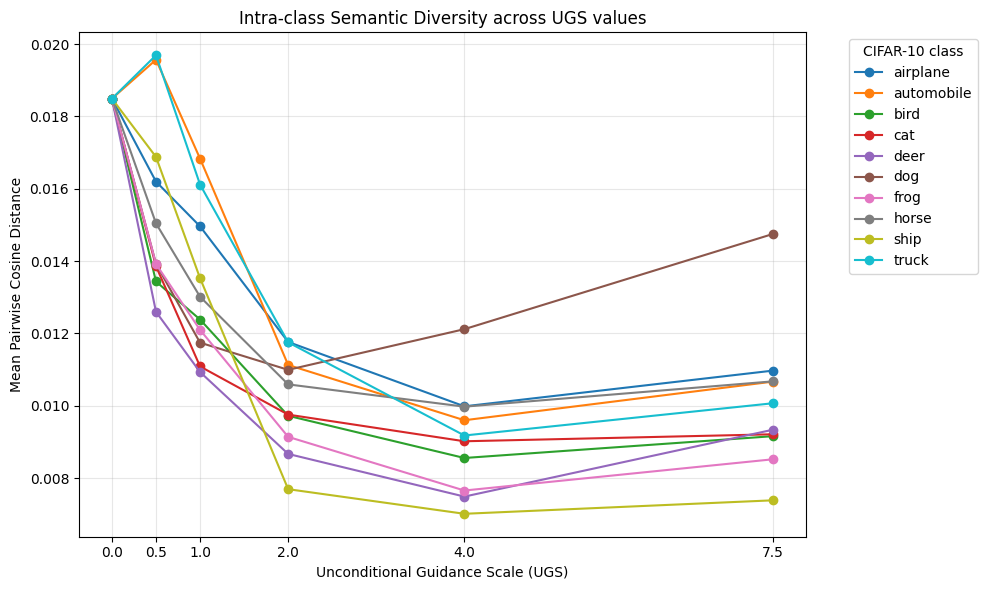

In [19]:
plt.figure(figsize=(10, 6))

diversity_df = pd.DataFrame(
    diversity_results,
    index=CLASS_NAMES
)

for class_name in CLASS_NAMES:
    plt.plot(
        UGS_VALUES,
        diversity_df.loc[class_name].values,
        marker="o",
        label=class_name
    )

plt.xlabel("Unconditional Guidance Scale (UGS)")
plt.ylabel("Mean Pairwise Cosine Distance")
plt.title("Intra-class Semantic Diversity across UGS values")

plt.xticks(UGS_VALUES)

plt.legend(
    title="CIFAR-10 class",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##### The results reveal an overall inverse relationship between guidance strength and intra-class semantic diversity. For most CIFAR-10 classes, the mean pairwise cosine distance decreases substantially as UGS increases from 0 to 2–4, suggesting that stronger conditioning makes the generated samples converge towards a narrower set of class-specific semantic features. At UGS = 7.5, several classes exhibit a modest increase in diversity, although their values generally remain below those observed under weak guidance. The dog class represents a notable exception, as its diversity increases steadily at higher UGS values, indicating a class-dependent response to guidance. Overall, UGS values around 2–4 appear to produce the most semantically homogeneous samples, while lower guidance preserves greater variability.

##### At UGS = 0, all classes have the same diversity value because the conditional class information is effectively ignored. Since the same random seed and initial noise samples are used for every class, the generator produces the same set of images regardless of the requested label. Therefore, this point should be interpreted as an unconditional baseline rather than as a class-specific diversity measurement.